# Laboratorio 3 — Selección de modelos y plan de procesamiento

Con los datos ya explorados (`01_eda.ipynb`) y preprocesados (`02_preprocesamiento.ipynb`),
este cuaderno define **qué modelos se van a entrenar, con qué entradas y bajo qué protocolo**.

## 1. Preparación del entorno

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers

sys.path.append(str(Path.cwd().parent / "src"))
import preprocess as pp

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
rng = np.random.default_rng(SEED)
plt.rcParams["figure.dpi"] = 100

print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.15.1 | backend: torch


In [2]:
datos, CLASES = pp.cargar_procesado(mmap=False)
X_train, y_train = datos["train"]
X_val, y_val = datos["val"]
X_test, y_test = datos["test"]

N_CLASES = len(CLASES)
FORMA = X_train.shape[1:]

print(f"entrenamiento: {X_train.shape}  ({X_train.nbytes / 1e6:.0f} MB)")
print(f"validacion:    {X_val.shape}")
print(f"prueba:        {X_test.shape}")
print(f"clases: {N_CLASES} | forma de entrada: {FORMA} | tipo: {X_train.dtype}")

entrenamiento: (10150, 64, 64, 3)  (125 MB)
validacion:    (2175, 64, 64, 3)
prueba:        (2175, 64, 64, 3)
clases: 29 | forma de entrada: (64, 64, 3) | tipo: uint8


## 2. La tarea y cómo se va a medir

El problema es de **clasificación multiclase con 29 categorías balanceadas**: dada una imagen
de 64×64 en color, decir cuál de las 29 señas muestra.

Métricas que se usarán en los ejercicios 4 al 7:

| Métrica | Por qué |
|---|---|
| **Exactitud (accuracy)** | Es interpretable y, como las 29 clases están perfectamente balanceadas, no engaña. La línea base de adivinar al azar es 1/29 ≈ 3.4 %. |
| **F1 macro** | Promedia el F1 de cada clase por igual. Detecta si el modelo es bueno en general pero falla sistemáticamente en dos o tres letras. |
| **Matriz de confusión** | Es la métrica clave de este laboratorio: muestra *qué* letra se confunde con *cuál*. Se revisará con especial atención en los pares que el EDA señaló como más parecidos. |
| **Curvas de aprendizaje** | Entrenamiento vs. validación por época, para detectar sobreajuste. |

**Cómo se usan las particiones**: el conjunto de **validación** (15 %, 2,175 imágenes) se usa
para comparar arquitecturas y ajustar hiperparámetros; se puede consultar tantas veces como sea
necesario. El conjunto de **prueba** (15 %) se toca **una sola vez**, al final, para reportar el
desempeño del modelo elegido. Mezclar los dos roles es la forma más común de reportar un
resultado inflado.

**Los pares a vigilar:** el análisis exploratorio identificó los grupos de letras cuyas señas
promedio son más parecidas entre sí, y por lo tanto los candidatos a confundirse:

- **U, V, R** — dedos extendidos que se diferencian por la separación entre ellos.
- **M, N, S** — puños cerrados que se diferencian por la posición del pulgar.
- **T, U, W, S, Y** — el grupo que los datos señalaron y que el enunciado no menciona.

## 3. Los cuatro modelos candidatos

| # | Modelo | Ejercicio | Idea central |
|---|---|---|---|
| 1 | **CNN-A** (línea base) | 4 | Dos bloques `Conv2D` + `MaxPooling2D`. Sirve de referencia: cualquier modelo más complejo debe superarla para justificar su costo. |
| 2 | **CNN-B** (profunda) | 4 | Tres bloques con normalización por lotes y `Dropout`. Más capacidad para captar los detalles finos que separan M de N o U de V. |
| 3 | **MLP** (red densa simple) | 5 | Aplana la imagen en un vector de 12,288 números. Ignora por completo la estructura espacial: es el contraste que demuestra por qué las convoluciones importan en imágenes. |
| 4 | **SVM con kernel RBF sobre PCA** | 6 | Un algoritmo clásico, sin redes neuronales. |

### ¿Por qué SVM y no Random Forest o KNN?

Los tres son opciones válidas para el ejercicio 6. Se elige **SVM con kernel RBF** por tres
razones concretas de este problema:

- **El tamaño de los datos le favorece.** Con 10,150 muestras de entrenamiento, una SVM entrena
  en minutos. Es justo el régimen en el que las SVM son competitivas; con cientos de miles de
  muestras dejarían de serlo por su costo cuadrático.
- **Maneja fronteras no lineales en espacios de muchas dimensiones.** El kernel RBF compara
  imágenes por su similitud global, que es la señal que el EDA mostró que existe: las señas de
  una misma letra se parecen entre sí.
- **PCA resuelve su punto débil.** Una SVM sobre 12,288 píxeles crudos sería lentísima.
  Reduciendo antes a 100 componentes principales se conserva la mayor parte de la varianza y el
  entrenamiento se vuelve manejable.

Aun así, en el ejercicio 6 se compararán las tres (SVM, Random Forest y KNN) con los mismos
datos y se reportará cuál gana en la práctica. También queda pendiente de ahí una tarea que
salió del cuaderno de preprocesamiento: **medir la entrada con bordes de Canny contra la escala
de grises**, porque Canny ganó la prueba de representaciones con un clasificador de vecinos.

### 3.1 CNN-A — línea base

Dos bloques convolucionales y una cabeza densa. Nótese que la capa `Rescaling(1/255)` va
**dentro** del modelo: así los arreglos pueden quedarse en `uint8` en memoria y la conversión a
decimales ocurre lote por lote, que es la decisión de preprocesamiento documentada en el
cuaderno anterior.

In [3]:
def construir_cnn_a():
    return keras.Sequential([
        keras.Input(shape=FORMA),
        layers.Rescaling(1 / 255.0),

        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(N_CLASES, activation="softmax"),
    ], name="CNN_A")

cnn_a = construir_cnn_a()
cnn_a.summary()

Model: "CNN_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,413 (8.09 MB)

 Trainable params: 2,120,413 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

El resumen revela que de los **2,120,413 parámetros** del modelo, **2,097,280 están en una sola capa**, el `Dense(128)` que viene después del `Flatten`. Es decir, el **99 %** de los pesos de esta red no está en las convoluciones sino en la capa densa que las sigue.

Esto anticipa el riesgo de esta arquitectura. Una capa densa tan grande es propensa al
sobreajuste, y de ahí que lleve un `Dropout(0.5)` antes de la salida.

### 3.2 CNN-B — más profunda y regularizada

Tres bloques convolucionales, con el doble de filtros en cada nivel que el anterior. Dos
añadidos respecto a CNN-A:

- **`BatchNormalization`** después de cada convolución: estabiliza y acelera el entrenamiento.
- **`GlobalAveragePooling2D`** en vez de `Flatten`: promedia cada mapa de rasgos en un solo
  número, lo que reduce muchísimo los parámetros de la cabeza densa y limita el sobreajuste.

In [4]:
def construir_cnn_b():
    modelo = keras.Sequential([keras.Input(shape=FORMA), layers.Rescaling(1 / 255.0)],
                              name="CNN_B")
    for filtros in (32, 64, 128):
        modelo.add(layers.Conv2D(filtros, 3, padding="same", use_bias=False))
        modelo.add(layers.BatchNormalization())
        modelo.add(layers.Activation("relu"))
        modelo.add(layers.MaxPooling2D(2))
        modelo.add(layers.Dropout(0.25))
    modelo.add(layers.GlobalAveragePooling2D())
    modelo.add(layers.Dense(256, activation="relu"))
    modelo.add(layers.Dropout(0.5))
    modelo.add(layers.Dense(N_CLASES, activation="softmax"))
    return modelo

cnn_b = construir_cnn_b()
cnn_b.summary()

Model: "CNN_B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,397 (524.99 KB)

 Trainable params: 133,949 (523.24 KB)

 Non-trainable params: 448 (1.75 KB)

El contraste con CNN-A es notable. CNN-B tiene **tres** bloques convolucionales en vez de dos, más filtros en cada nivel (32, 64 y 128) y capas de normalización adicionales, y aun así usa **134,397 parámetros**, unas **16 veces menos** que CNN-A.

Nota: aparecen **448 parámetros no entrenables**. Son las medias y varianzas que las capas `BatchNormalization` acumulan durante el entrenamiento para usarlas en inferencia; no se aprenden por descenso de gradiente.

### 3.3 MLP — red neuronal simple (fully-connected)

Esta red aplana la imagen: los 64×64×3 = 12,288 valores se convierten en un vector y se alimentan a capas densas.

In [5]:
def construir_mlp():
    return keras.Sequential([
        keras.Input(shape=FORMA),
        layers.Rescaling(1 / 255.0),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(N_CLASES, activation="softmax"),
    ], name="MLP")

mlp = construir_mlp()
mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,430,749 (24.53 MB)

 Trainable params: 6,430,749 (24.53 MB)

 Non-trainable params: 0 (0.00 B)

El MLP es, con **6,430,749 parámetros**, el modelo **más grande de los tres** (tres veces CNN-A y casi cincuenta veces CNN-B). Y sin embargo es el que menos estructura aprovecha.

Más parámetros no significan mejor modelo cuando la arquitectura no encaja con la estructura del problema.

### 3.4 SVM sobre PCA — el algoritmo clásico

No es una red neuronal, así que necesita una entrada distinta: un **vector plano**. El
canalizador (`Pipeline`) de scikit-learn encadena tres pasos que siempre se aplican juntos, lo
que evita el error de ajustar el escalador o el PCA con datos de prueba:

1. `StandardScaler` — centra y escala cada característica.
2. `PCA(100)` — reduce de 4,096 dimensiones (imagen en grises) a 100 componentes.
3. `SVC(kernel="rbf")` — el clasificador.

In [6]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def a_vector_gris(X):
    """Convierte (n, 64, 64, 3) uint8 en (n, 4096) float32 en escala de grises [0,1]."""
    gris = X @ np.array([0.299, 0.587, 0.114], dtype="float32")
    return (gris.reshape(len(X), -1) / 255.0).astype("float32")

svm = Pipeline([
    ("escala", StandardScaler()),
    ("pca", PCA(n_components=100, random_state=SEED)),
    ("svc", SVC(kernel="rbf", C=10, gamma="scale", random_state=SEED)),
])

ejemplo_vector = a_vector_gris(X_train[:100])
print(f"Entrada para los modelos clasicos: {ejemplo_vector.shape[1]:,} dimensiones por imagen")
print(f"Todo el conjunto de entrenamiento ocuparia "
      f"{len(X_train) * ejemplo_vector.shape[1] * 4 / 1e6:.0f} MB en float32")
print()
print(svm)

Entrada para los modelos clasicos: 4,096 dimensiones por imagen
Todo el conjunto de entrenamiento ocuparia 166 MB en float32

Pipeline(steps=[('escala', StandardScaler()),
                ('pca', PCA(n_components=100, random_state=42)),
                ('svc', SVC(C=10, random_state=42))])


El vector en escala de grises tiene **4,096 dimensiones** por imagen, un tercio de las 12,288 que consumen las redes. Todo el conjunto de entrenamiento ocuparía **166 MB** en `float32`, que cabe sin problema en la memoria disponible.

El `Pipeline` se imprime mostrando sus tres etapas en orden. La ventaja de encapsularlas así es que al llamar `fit` solo con los datos de entrenamiento, el escalador y el PCA se ajustan **únicamente** con esos datos. Si se hicieran por separado sería fácil calcularlos sobre todo el conjunto y filtrar información del conjunto de prueba, un error silencioso y muy común.

## 4. Qué entrada consume cada modelo

| Modelo | Entrada | Normalización | Dónde ocurre |
|---|---|---|---|
| CNN-A, CNN-B | Tensor `(n, 64, 64, 3)` en `uint8` | ÷255 → [0, 1] | Capa `Rescaling` dentro del modelo, lote por lote |
| MLP | El mismo tensor, aplanado por la capa `Flatten` | ÷255 → [0, 1] | Capa `Rescaling` dentro del modelo |
| SVM / RF / KNN | Vector `(n, 4096)` en escala de grises | ÷255, luego `StandardScaler` + PCA | En el `Pipeline` de scikit-learn, ajustado solo con datos de entrenamiento |

Se usa escala de grises para el modelo clásico por una razón medida: reduce la entrada a un
tercio (de 12,288 a 4,096 valores) y en la prueba del cuaderno anterior la escala de grises
superó al RGB con un clasificador de vecinos, lo cual es coherente con el hallazgo del EDA de
que el color casi no varía entre clases.

## 5. Plan de aumento de datos (adelanto del ejercicio 7)

El aumento de datos crea variaciones artificiales de las imágenes de entrenamiento para que el
modelo aprenda a ser robusto. Pero en lenguaje de señas **no cualquier transformación es
válida**, porque la orientación y la lateralidad son parte del significado.

### Transformaciones que sí tienen sentido

| Transformación | Rango propuesto | Qué simula | Respaldo en el EDA |
|---|---|---|---|
| Brillo / contraste | ±20 % | Distintas condiciones de iluminación | Es la mayor fuente de variación del dataset: en la letra A el brillo medio va de 80 a 160 entre tomas |
| Zoom | ±10 % | Mano más cerca o más lejos de la cámara | Se observó que el tamaño de la mano cambia entre fotos |
| Traslación | ±10 % | Mano no centrada en el encuadre | Las imágenes promedio salen borrosas justamente porque la mano se mueve de posición |
| Rotación pequeña | ±10° | Inclinación de la muñeca | Se observa variación de unos pocos grados entre tomas |

Todas reproducen variaciones que **ya existen** en los datos reales, que es el criterio correcto
para elegir una transformación.

Una nota conectada con el cuaderno anterior fue justamente al preparar estas transformaciones
que se descubrió el **marco azul** grabado en el borde de las fotografías. Cualquier traslación o
zoom lo arrastraba hacia el interior y lo convertía en una banda azul ancha. Como ese borde ya se
recorta en el preprocesamiento, las capas de aumento ahora operan sobre imágenes limpias.

### Transformaciones que no

| Transformación | Por qué no |
|---|---|
| **Volteo horizontal** | Ver la demostración de abajo |
| **Volteo vertical** | Produce manos de cabeza, una situación que jamás ocurre frente a una cámara |
| **Rotaciones grandes (>30°)** | La orientación de la mano distingue señas entre sí; girarla puede convertir una letra en otra |
| **Recortes agresivos** | Pueden cortar los dedos, que es justamente donde está la información que distingue las letras |

### ¿Por qué un volteo horizontal cambia el significado de una seña en vez de solo aumentar los datos?

1. **Todo el dataset es de la mano derecha.** Voltear horizontalmente produce una mano
   izquierda. Es una imagen que sí existe en la vida real (hay personas zurdas), pero el modelo
   aprendería a tratar ambas manos como equivalentes sin que ninguna etiqueta lo respalde. Si
   de verdad se quiere cubrir a personas zurdas, lo correcto es **grabar datos de manos
   izquierdas**, no inventarlos por espejo.
2. **Hay señas cuya dirección es parte de la letra.** Las letras **G** y **H** apuntan
   lateralmente, y **P** y **Q** apuntan hacia abajo con una orientación específica. Al
   espejarlas, el dedo que apuntaba a la derecha ahora apunta a la izquierda: ya no es la misma
   configuración. El modelo estaría entrenando con una imagen alterada bajo una etiqueta que ya
   no le corresponde. **Eso no aumenta los datos, los contamina**: se le está enseñando
   activamente algo falso.

La figura siguiente muestra el efecto sobre esas cuatro letras direccionales.

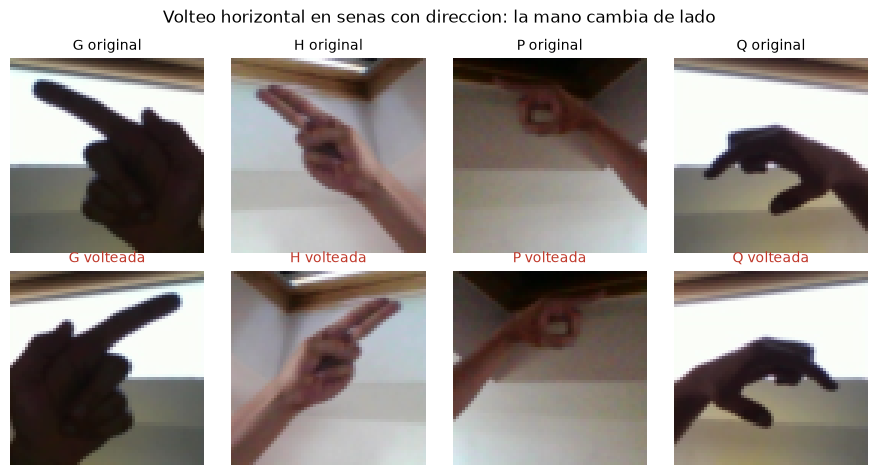

In [7]:
letras_direccionales = ["G", "H", "P", "Q"]
idx_por_letra = {letra: np.where(y_train == CLASES.index(letra))[0][0]
                 for letra in letras_direccionales}

fig, axes = plt.subplots(2, len(letras_direccionales), figsize=(9, 4.8))
for col, letra in enumerate(letras_direccionales):
    img = X_train[idx_por_letra[letra]]
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"{letra} original", fontsize=10)
    axes[1, col].imshow(img[:, ::-1])          # volteo horizontal
    axes[1, col].set_title(f"{letra} volteada", fontsize=10, color="#c0392b")
for ax in axes.flat:
    ax.axis("off")
fig.suptitle("Volteo horizontal en senas con direccion: la mano cambia de lado")
plt.tight_layout()
plt.show()

La figura confirma el argumento con evidencia visual. En las cuatro letras la mano **cambia de lado**:

- La **G** original apunta con el índice hacia la derecha; volteada, apunta hacia la izquierda.
- Lo mismo pasa con la **H**, y con la **P** y la **Q**, cuyas orientaciones también quedan
  invertidas.

Ninguna de las imágenes de abajo es una fotografía plausible de la seña que dice su etiqueta. Si
se agregaran al entrenamiento con esa etiqueta, se le estaría enseñando al modelo una asociación
falsa. Por eso el volteo horizontal queda descartado, aunque sea la transformación de aumento más
común en clasificación de imágenes en general.

### Cómo se verán las transformaciones que sí se usan

Keras aplica estas capas **solo durante el entrenamiento**; en validación y prueba quedan
inactivas de forma automática, lo cual es importante: nunca se debe evaluar sobre imágenes
alteradas.

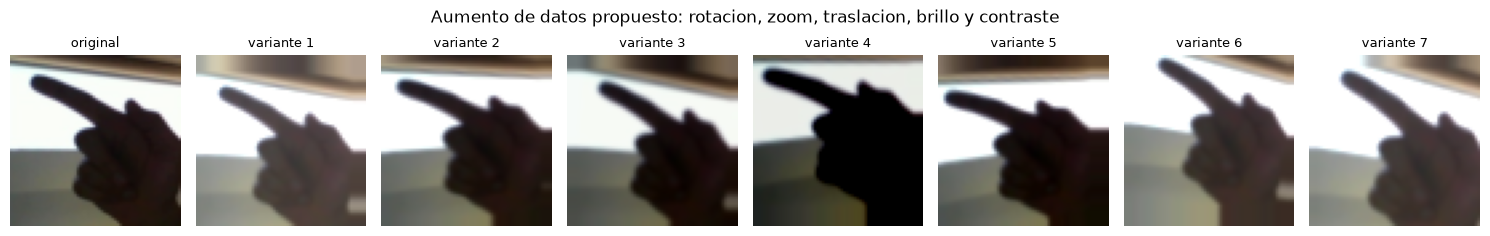

rango de las variantes: [0.00, 1.00]


In [8]:
# Las capas de aumento operan sobre la imagen ya normalizada a [0, 1], que es
# exactamente donde iran en el modelo: justo despues de la capa Rescaling.
# fill_mode="nearest" evita inventar colores en los bordes al mover la imagen.
aumento = keras.Sequential([
    layers.RandomRotation(0.03, fill_mode="nearest"),      # ~ +/- 10 grados
    layers.RandomZoom(0.10, fill_mode="nearest"),
    layers.RandomTranslation(0.10, 0.10, fill_mode="nearest"),
    layers.RandomBrightness(0.20, value_range=(0.0, 1.0)),
    layers.RandomContrast(0.20),
], name="aumento_de_datos")

base = X_train[idx_por_letra["G"]]
lote = np.repeat((base[None, ...] / 255.0).astype("float32"), 7, axis=0)
variantes = np.clip(np.asarray(aumento(lote, training=True)), 0.0, 1.0)

fig, axes = plt.subplots(1, 8, figsize=(15, 2.4))
axes[0].imshow(base)
axes[0].set_title("original", fontsize=9)
for k in range(7):
    axes[k + 1].imshow(variantes[k])
    axes[k + 1].set_title(f"variante {k + 1}", fontsize=9)
for ax in axes.flat:
    ax.axis("off")
fig.suptitle("Aumento de datos propuesto: rotacion, zoom, traslacion, brillo y contraste")
plt.tight_layout()
plt.show()

print(f"rango de las variantes: [{variantes.min():.2f}, {variantes.max():.2f}]")

**Interpretación**: Las siete variantes son todas fotografías plausibles de la misma seña. La
mano se mueve dentro del encuadre, cambia de tamaño, se inclina un poco y varía de iluminación,
pero **sigue siendo una G apuntando a la derecha**. Eso es lo que debe lograr un buen aumento de
datos: ampliar la variedad sin cambiar el significado.

La **variante 4** quedó muy oscura, casi una silueta. Podría parecer excesiva, pero el EDA mostró que el dataset **ya contiene** fotos así (en la letra A el brillo medio baja hasta 80 sobre 255), así que es una variación realista y útil para que el modelo aprenda a no depender de la iluminación.

También se confirma que el rango de salida se mantiene en [0.00, 1.00], que es lo que las capas siguientes de la red esperan.

## 6. Protocolo de entrenamiento propuesto


| Parámetro | Valor | Por qué |
|---|---|---|
| `batch_size` | 64 | Buen equilibrio en CPU: lotes más pequeños desperdician paralelismo, lotes más grandes no caben cómodamente en la memoria disponible |
| `optimizer` | `adam` | Converge rápido sin necesidad de ajustar la tasa de aprendizaje a mano |
| `loss` | `sparse_categorical_crossentropy` | Las etiquetas son enteros de 0 a 28, no vectores one-hot |
| Épocas máximas | 20 | Es el límite que cabe en el presupuesto de cómputo medido |
| `EarlyStopping` | `monitor="val_accuracy"`, `patience=4`, `restore_best_weights=True` | Detiene el entrenamiento cuando la validación deja de mejorar y recupera los mejores pesos. En la práctica casi siempre parará antes de las 20 épocas, así que el costo real será menor |
| Validación | el conjunto de validación del 15 %, explícito | Se pasa con `validation_data`, no con `validation_split`, para usar exactamente la partición estratificada ya creada |

**Orden de trabajo propuesto para los ejercicios 4 al 7:**

1. Entrenar **CNN-A** como línea base y **CNN-B** para comparar, ambas sin aumento de datos.
2. Entrenar el **MLP** con la misma configuración (ejercicio 5). Es el más rápido, así que
   permite probar varias combinaciones de capas y `dropout` sin gastar mucho tiempo.
3. Entrenar el **modelo clásico** ajustando `C` y `gamma`, y compararlo contra Random Forest y
   KNN (ejercicio 6). Aquí también hay que medir la entrada con **bordes de Canny** contra la
   escala de grises, que fue la tarea que quedó pendiente del cuaderno de preprocesamiento.
4. Volver a entrenar la mejor CNN **con aumento de datos** (ejercicio 7) y comparar contra su
   versión sin aumento.
5. Revisar la **matriz de confusión** del mejor modelo en los grupos que señaló el EDA: U/V/R,
   M/N/S y T/U/W/S/Y.

**Nota**: al aplicar el aumento de datos, se encarece cada época, porque las transformaciones se calculan sobre la marcha para cada lote. Por tanto, se reserva para la arquitectura que ya haya ganado sin aumento, en lugar de aplicarlo a todas.

## 8. Resumen

### Lo que queda definido

| Modelo | Ejercicio | Parámetros | Entrada |
|---|---|---|---|
| **CNN-A** | 4 | 2,120,413 | Tensor RGB 64×64 en `uint8` |
| **CNN-B** | 4 | 134,397 | Tensor RGB 64×64 en `uint8` |
| **MLP** | 5 | 6,430,749 | El mismo tensor, aplanado |
| **SVM (RBF) + PCA** | 6 | — | Vector de 4,096 valores en escala de grises |

Con `batch_size` 64, `adam`, hasta 20 épocas y `EarlyStopping` sobre `val_accuracy`. Métricas:
exactitud, F1 macro y matriz de confusión, midiendo en validación y reservando el conjunto de
prueba para el final.